<a href="https://colab.research.google.com/github/najmulhoda3020/Traffic-Analysis-Using-ML/blob/main/Major_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Initial Setup: Mount Drive, Install & Import Libraries**

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import os

# Searching drive for the file
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'US_Accidents' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/accident_hotspots/data/US_Accidents_March23.csv


In [49]:
!pip install folium xgboost shap streamlit pyngrok streamlit-folium -q
print("✅ Done!")

✅ Done!


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import folium
from folium.plugins import HeatMap

print("✅ All libraries imported!")

✅ All libraries imported!


### **2. Accident Data Loading and Preprocessing**

In [51]:
FILE_PATH = '/content/drive/MyDrive/accident_hotspots/data/US_Accidents_March23.csv'

print("⏳ Loading file... (may take 1-2 mins, file is large)")

df = pd.read_csv(FILE_PATH, nrows=100000)

print(f"✅ Loaded! Shape: {df.shape}")
display(df.head(3))

⏳ Loading file... (may take 1-2 mins, file is large)
✅ Loaded! Shape: (100000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day


In [52]:
print("🔧 Preprocessing...")

# Selecting relevent columns
df = df[['Severity', 'Start_Lat', 'Start_Lng',
         'Weather_Condition', 'Visibility(mi)',
         'Temperature(F)', 'Humidity(%)',
         'Wind_Speed(mph)', 'Precipitation(in)',
         'Start_Time', 'Sunrise_Sunset',
         'Junction', 'Traffic_Signal',
         'Crossing', 'City', 'State']].copy()

# Renaming for convenience
df.rename(columns={
    'Start_Lat'       : 'Latitude',
    'Start_Lng'       : 'Longitude',
    'Visibility(mi)'  : 'Visibility',
    'Temperature(F)'  : 'Temperature',
    'Humidity(%)'     : 'Humidity',
    'Wind_Speed(mph)' : 'Wind_Speed',
    'Precipitation(in)':'Precipitation'
}, inplace=True)

# Parse datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Hour']       = df['Start_Time'].dt.hour
df['Month']      = df['Start_Time'].dt.month
df['DayOfWeek']  = df['Start_Time'].dt.dayofweek
df['Year']       = df['Start_Time'].dt.year

# Drop rows with missing values
df.dropna(subset=['Severity','Latitude','Longitude',
                  'Weather_Condition','Visibility'], inplace=True)

# Fill remaining nulls
df['Temperature'].fillna(df['Temperature'].median(), inplace=True)
df['Humidity'].fillna(df['Humidity'].median(), inplace=True)
df['Wind_Speed'].fillna(0, inplace=True)
df['Precipitation'].fillna(0, inplace=True)
df['Sunrise_Sunset'].fillna('Day', inplace=True)

# Encode categoricals
le_weather  = LabelEncoder()
le_daynight = LabelEncoder()
df['Weather_Encoded']  = le_weather.fit_transform(df['Weather_Condition'])
df['DayNight_Encoded'] = le_daynight.fit_transform(df['Sunrise_Sunset'])
df['Junction']         = df['Junction'].astype(int)
df['Traffic_Signal']   = df['Traffic_Signal'].astype(int)
df['Crossing']         = df['Crossing'].astype(int)

# Severity label
def map_severity(s):
    if s <= 2: return 'Minor'
    elif s == 3: return 'Serious'
    else: return 'Severe'

df['Severity_Label'] = df['Severity'].apply(map_severity)

# Weather risk score (for risk engine)
weather_risk_map = {
    'Clear':0.1, 'Fair':0.1, 'Partly Cloudy':0.2,
    'Mostly Cloudy':0.2, 'Cloudy':0.2, 'Overcast':0.25,
    'Haze':0.3, 'Fog':0.7, 'Light Rain':0.5,
    'Rain':0.6, 'Heavy Rain':0.8, 'Light Snow':0.6,
    'Snow':0.8, 'Heavy Snow':0.9, 'Thunderstorm':0.9,
    'Blowing Snow':0.85, 'Wintry Mix':0.75
}
df['Weather_Risk'] = df['Weather_Condition'].map(weather_risk_map)
df['Weather_Risk'].fillna(0.35, inplace=True)

# Normalize visibility (inverted: low visibility = high risk)
df['Visibility_Norm'] = 1 - (df['Visibility'] / df['Visibility'].max())

print(f"✅ Preprocessing done! Clean rows: {len(df):,}")
print("\nSeverity Distribution:")
print(df['Severity_Label'].value_counts())

🔧 Preprocessing...
✅ Preprocessing done! Clean rows: 97,833

Severity Distribution:
Severity_Label
Minor      53831
Serious    43969
Severe        33
Name: count, dtype: int64


In [53]:
print("🔧 Checking severity distribution...")
print(df['Severity'].value_counts().sort_index())

# Remap severity — 3 balanced classes
def map_severity_fixed(s):
    if s == 1:   return 'Low'
    elif s == 2: return 'Medium'
    else:        return 'High'   # Severity 3 AND 4 included here

df['Severity_Label'] = df['Severity'].apply(map_severity_fixed)

print("\nNew class distribution:")
print(df['Severity_Label'].value_counts())

🔧 Checking severity distribution...
Severity
1       95
2    53736
3    43969
4       33
Name: count, dtype: int64

New class distribution:
Severity_Label
Medium    53736
High      44002
Low          95
Name: count, dtype: int64


### **3. Accident Data Exploratory Data Analysis (EDA)**

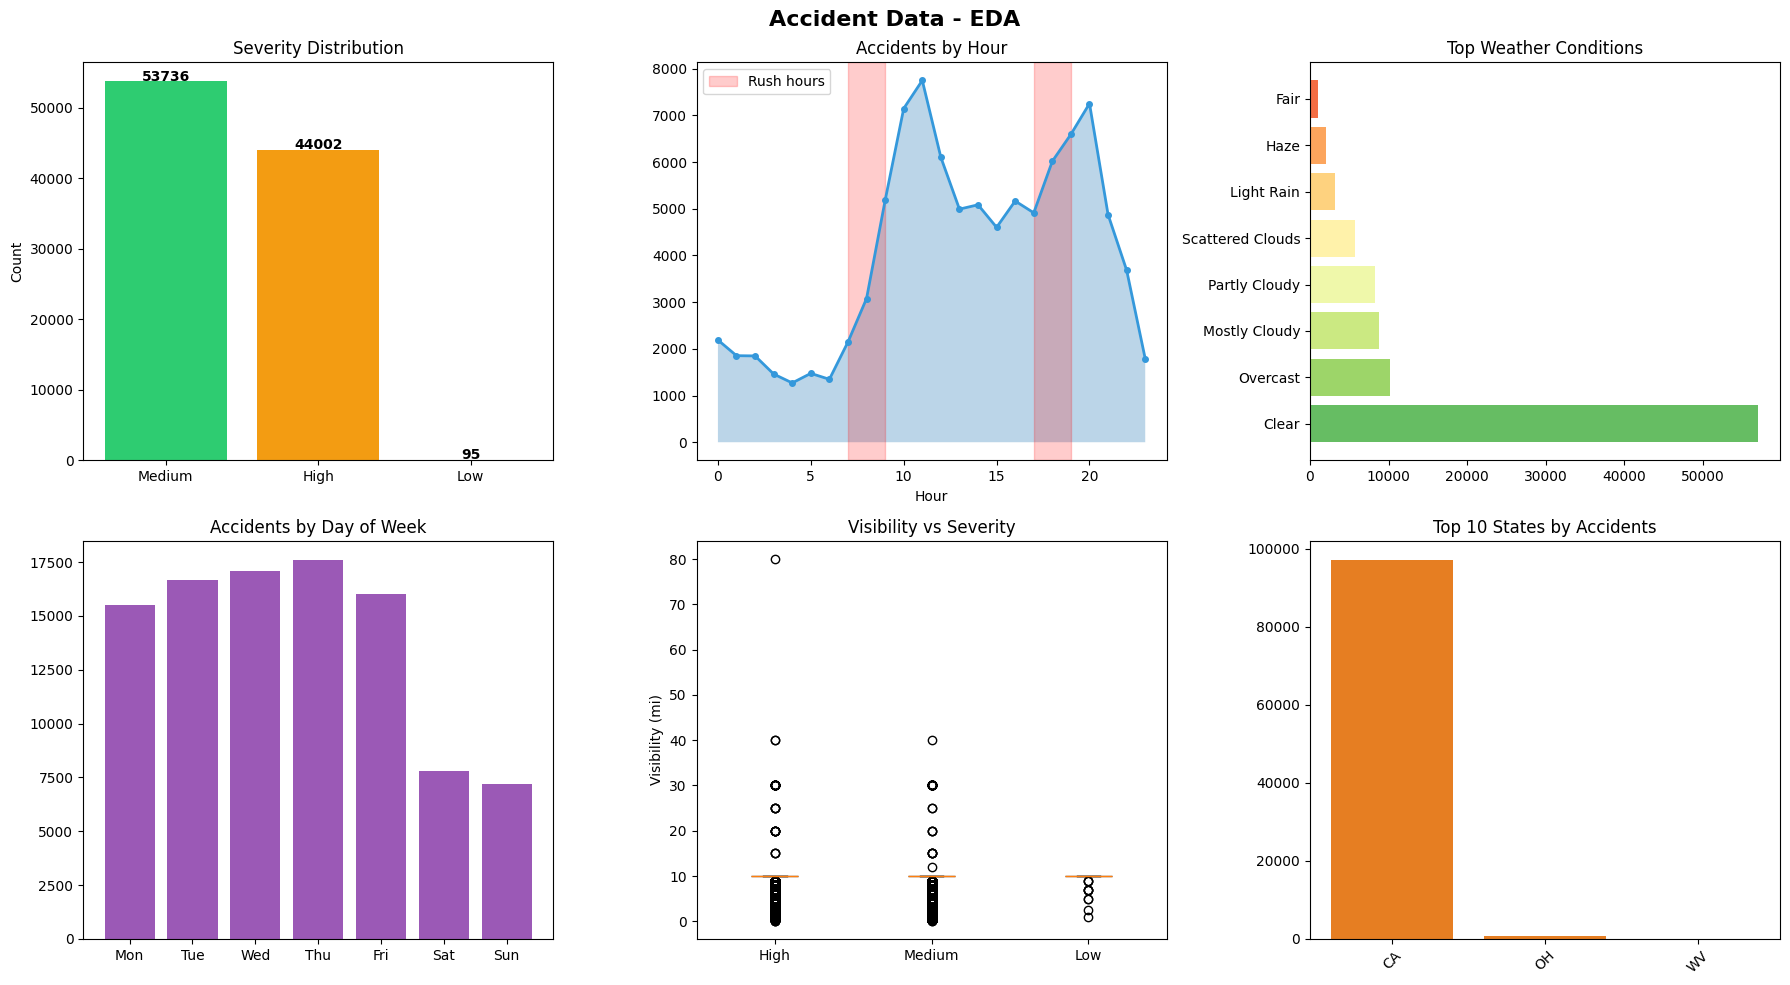

✅ EDA done!


In [54]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Accident Data - EDA', fontsize=16, fontweight='bold')

# 1. Severity
sv = df['Severity_Label'].value_counts()
axes[0,0].bar(sv.index, sv.values,
              color=['#2ecc71','#f39c12','#e74c3c'])
axes[0,0].set_title('Severity Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(sv.values):
    axes[0,0].text(i, v+100, str(v), ha='center', fontweight='bold')

# 2. Accidents by Hour
hourly = df['Hour'].value_counts().sort_index()
axes[0,1].plot(hourly.index, hourly.values,
               color='#3498db', linewidth=2, marker='o', markersize=4)
axes[0,1].fill_between(hourly.index, hourly.values, alpha=0.3)
axes[0,1].axvspan(7, 9, alpha=0.2, color='red', label='Rush hours')
axes[0,1].axvspan(17, 19, alpha=0.2, color='red')
axes[0,1].set_title('Accidents by Hour')
axes[0,1].set_xlabel('Hour')
axes[0,1].legend()

# 3. Top Weather Conditions
wc = df['Weather_Condition'].value_counts().head(8)
axes[0,2].barh(wc.index, wc.values,
               color=plt.cm.RdYlGn_r(np.linspace(0.2,0.8,len(wc))))
axes[0,2].set_title('Top Weather Conditions')

# 4. Day of Week
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow  = df['DayOfWeek'].value_counts().sort_index()
axes[1,0].bar(days, dow.values, color='#9b59b6')
axes[1,0].set_title('Accidents by Day of Week')

# 5. Visibility vs Severity
# Finding actual labels dynamically data
actual_labels = df['Severity_Label'].dropna().unique().tolist()

data_to_plot = [
    df[df['Severity_Label'] == s]['Visibility'].dropna()
    for s in actual_labels
]

# Filter out Empty lists
filtered = [(d, l) for d, l in zip(data_to_plot, actual_labels) if len(d) > 0]

if filtered:
    data_filtered, labels_filtered = zip(*filtered)
    axes[1,1].boxplot(
        data_filtered,
        labels=labels_filtered,
        patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.7)
    )
else:
    axes[1,1].text(0.5, 0.5, 'No data available',
                   ha='center', va='center', transform=axes[1,1].transAxes)

axes[1,1].set_title('Visibility vs Severity')
axes[1,1].set_ylabel('Visibility (mi)')

# 6. Top 10 States
top_states = df['State'].value_counts().head(10)
axes[1,2].bar(top_states.index, top_states.values, color='#e67e22')
axes[1,2].set_title('Top 10 States by Accidents')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA done!")

In [55]:
# Actual labels dynamically
actual_labels = df['Severity_Label'].dropna().unique().tolist()

data_to_plot = [
    df[df['Severity_Label'] == s]['Visibility'].dropna()
    for s in actual_labels
]

# Empty lists filter
filtered = [(d, l) for d, l in zip(data_to_plot, actual_labels) if len(d) > 0]

if filtered:
    data_filtered, labels_filtered = zip(*filtered)
    axes[1,1].boxplot(
        data_filtered,
        labels=labels_filtered,
        patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.7)
    )
else:
    axes[1,1].text(0.5, 0.5, 'No data available',
                   ha='center', va='center', transform=axes[1,1].transAxes)

axes[1,1].set_title('Visibility vs Severity')
axes[1,1].set_ylabel('Visibility (mi)')

Text(663.6481481481483, 0.5, 'Visibility (mi)')

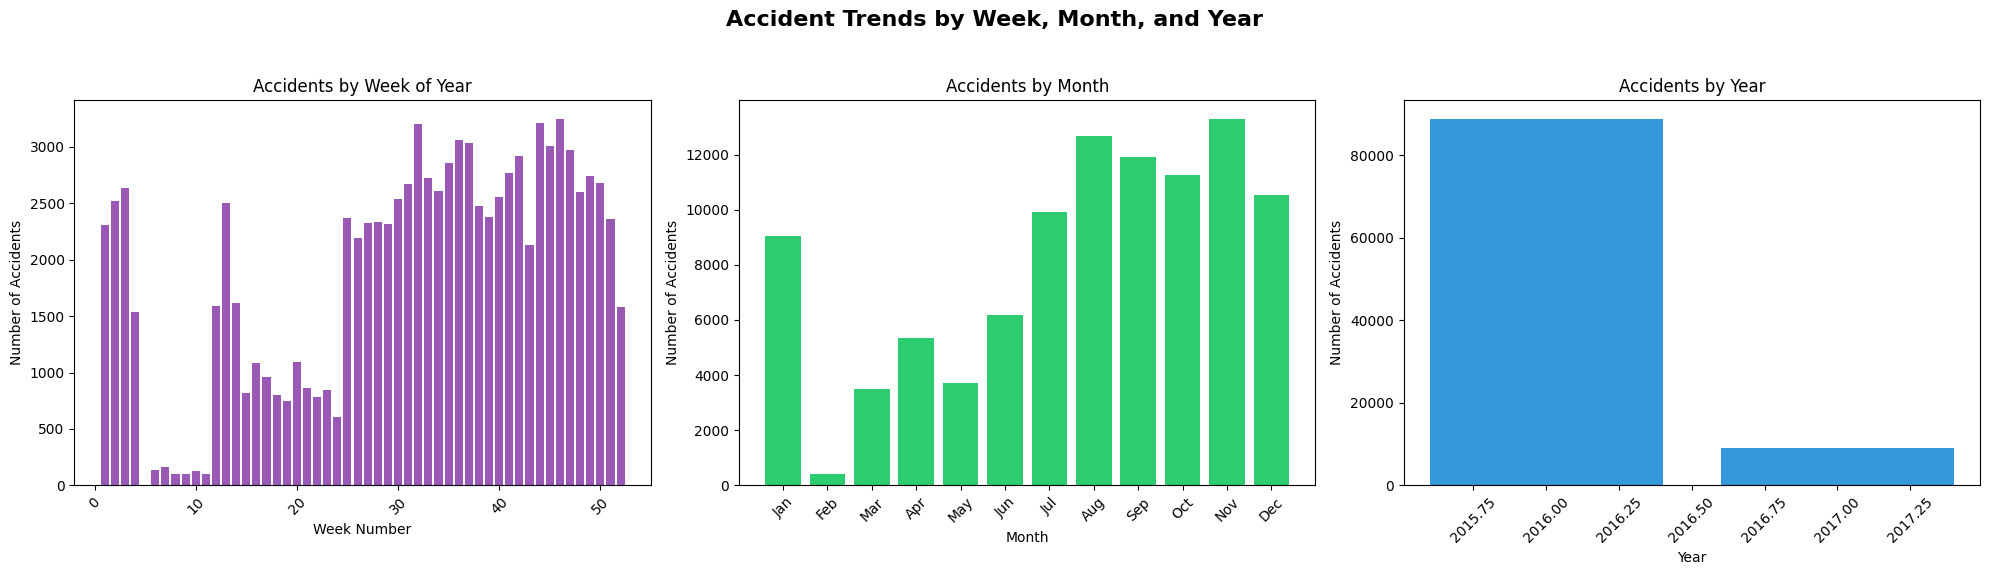

✅ Additional trend analysis complete!


In [56]:
# Accident Trends by Week, Month, and Year

import matplotlib.pyplot as plt
import seaborn as sns

# Extract week number
df['Week'] = df['Start_Time'].dt.isocalendar().week

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Accident Trends by Week, Month, and Year', fontsize=16, fontweight='bold')

# Accidents by Week
weekly = df['Week'].value_counts().sort_index()
axes[0].bar(weekly.index, weekly.values, color='#9b59b6')
axes[0].set_title('Accidents by Week of Year')
axes[0].set_xlabel('Week Number')
axes[0].set_ylabel('Number of Accidents')
axes[0].tick_params(axis='x', rotation=45)

# Accidents by Month
monthly = df['Month'].value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly.index, monthly.values, color='#2ecc71')
axes[1].set_title('Accidents by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Accidents')
axes[1].set_xticks(range(1, 13), month_names, rotation=45)

# Accidents by Year
yearly = df['Year'].value_counts().sort_index()
axes[2].bar(yearly.index, yearly.values, color='#3498db')
axes[2].set_title('Accidents by Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Number of Accidents')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('accident_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Additional trend analysis complete!")

In [57]:
import os
# Saving accident trend data for Streamlit (website)
df['Week'] = df['Start_Time'].dt.isocalendar().week

accident_trends = {
    'weekly':  df['Week'].value_counts().sort_index(),
    'monthly': df['Month'].value_counts().sort_index(),
    'yearly':  df['Year'].value_counts().sort_index()
}

import pickle
os.makedirs('saved_models', exist_ok=True)
pickle.dump(accident_trends, open('saved_models/accident_trends.pkl', 'wb'))
print("✅ Accident trends saved!")

✅ Accident trends saved!


📍 Detecting hotspots with KMeans...


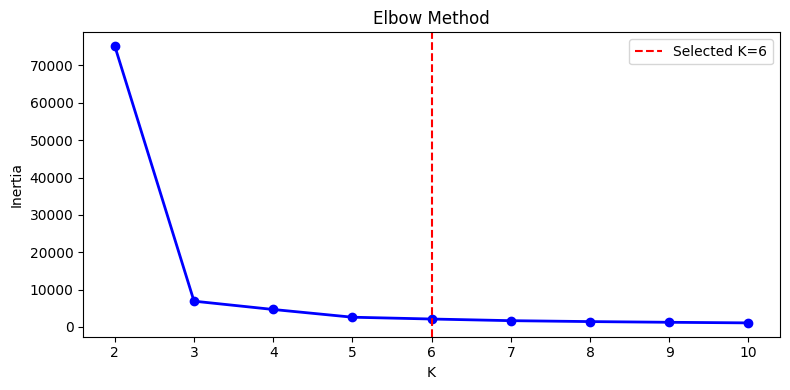

✅ Hotspots detected!
Hotspot_Density
High        65833
Moderate    22934
Low          9066
Name: count, dtype: int64

Centroids:


,Latitude,Longitude,Density
0,37.298104,-121.871193,Moderate
1,32.972151,-117.110093,Low
2,39.954915,-83.534946,Low
3,38.625695,-121.415696,Moderate
4,37.904178,-122.119591,High
5,34.019006,-118.056264,High


In [58]:
print("📍 Detecting hotspots with KMeans...")

coords        = df[['Latitude','Longitude']].values
scaler_coords = StandardScaler()
coords_scaled = scaler_coords.fit_transform(coords)

# Elbow method
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(2,11), inertias, 'bo-', linewidth=2)
plt.axvline(x=6, color='red', linestyle='--', label='Selected K=6')
plt.xlabel('K'); plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.legend(); plt.tight_layout()
plt.savefig('elbow.png', dpi=150); plt.show()

# Final KMeans
kmeans     = KMeans(n_clusters=6, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(coords_scaled)

# Labeling clusters by size → density
sizes  = df['Cluster'].value_counts()
sorted_c = sizes.sort_values(ascending=False)
labels = ['High','High','Moderate','Moderate','Low','Low']
density_map = {cid: labels[i]
               for i, (cid, _) in enumerate(sorted_c.items())}
df['Hotspot_Density'] = df['Cluster'].map(density_map)

density_score_map = {'High':1.0, 'Moderate':0.5, 'Low':0.1}
df['Accident_Density_Score'] = df['Hotspot_Density'].map(density_score_map)

# Centroids
centroids = scaler_coords.inverse_transform(kmeans.cluster_centers_)
hotspot_centroids = pd.DataFrame(centroids,
                    columns=['Latitude','Longitude'])
hotspot_centroids['Density'] = [density_map[i] for i in range(6)]

print("✅ Hotspots detected!")
print(df['Hotspot_Density'].value_counts())
print("\nCentroids:"); display(hotspot_centroids)

Accident counts by Weather Condition and Hour:


Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Weather_Condition,,,,,,,,,,,,,,,,,,,,,
Blowing Dust / Windy,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Blowing Sand,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
Clear,1343,986,938,702,575,651,572,875,1240,2363,...,3115,2815,3198,3260,3874,4318,4729,3184,2415,1179
Cloudy,3,3,7,3,9,9,9,10,13,10,...,12,3,5,5,3,7,1,5,3,4
Drizzle,3,0,0,0,0,0,2,0,3,4,...,1,0,4,3,2,3,1,1,0,1


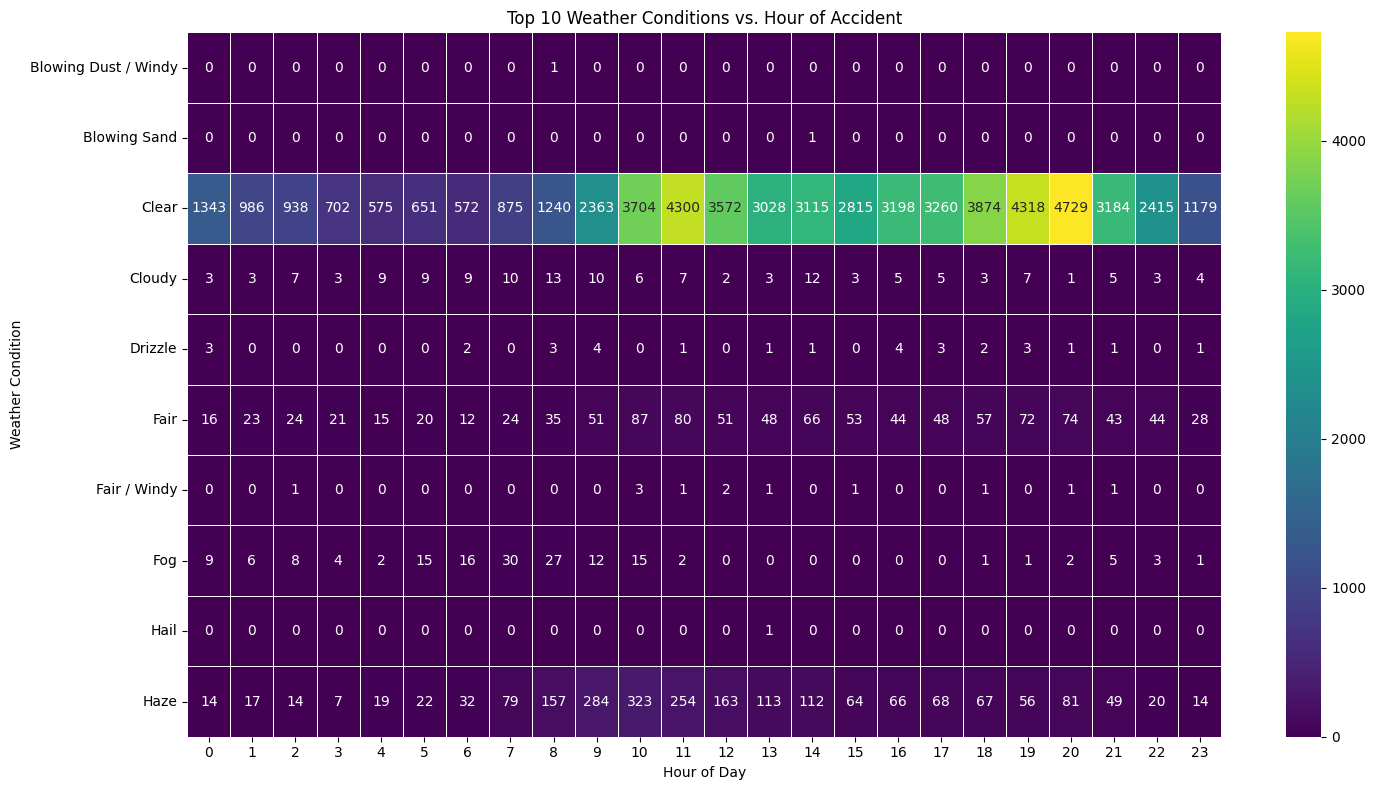

✅ Weather-Time analysis complete!


In [59]:
# Calculating accident counts by Weather Condition and Hour for heatmap in Streamlit
weather_time_analysis = df.groupby(['Weather_Condition', 'Hour']).size().unstack(fill_value=0)

print("Accident counts by Weather Condition and Hour:")
display(weather_time_analysis.head())

# visualizing this data as a heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(weather_time_analysis.head(10), cmap='viridis', annot=True, fmt='d', linewidths=.5)
plt.title('Top 10 Weather Conditions vs. Hour of Accident')
plt.xlabel('Hour of Day')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.show()
print("✅ Weather-Time analysis complete!")

### **4. Accident Severity Prediction Model Training**

In [60]:
from imblearn.over_sampling import SMOTE

print("🤖 Training models with fixed labels...")

FEATURES = ['Weather_Encoded', 'Visibility', 'Temperature',
            'Humidity', 'Wind_Speed', 'Precipitation',
            'Hour', 'Month', 'DayOfWeek',
            'DayNight_Encoded', 'Junction',
            'Traffic_Signal', 'Crossing',
            'Visibility_Norm', 'Weather_Risk']

le_severity            = LabelEncoder()
df['Severity_Encoded'] = le_severity.fit_transform(df['Severity_Label'])

print("Classes:", list(le_severity.classes_))

X = df[FEATURES].fillna(0)
y = df['Severity_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_train)
X_te_s   = scaler.transform(X_test)

# SMOTE on balanced classes
smote          = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_s, y_train)

print("After SMOTE:", pd.Series(
    le_severity.inverse_transform(y_tr_bal)).value_counts())

# Random Forest
print("\n  Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    random_state=42, n_jobs=-1)
rf.fit(X_tr_bal, y_tr_bal)
rf_pred = rf.predict(X_te_s)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"  ✅ RF Accuracy: {rf_acc:.4f}")

# XGBoost
print("  Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, random_state=42,
    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_tr_bal, y_tr_bal)
xgb_pred = xgb.predict(X_te_s)
xgb_acc  = accuracy_score(y_test, xgb_pred)
print(f"  ✅ XGB Accuracy: {xgb_acc:.4f}")

# Logistic Regression
print("  Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000, random_state=42,
    class_weight='balanced', C=1.0)
lr.fit(X_tr_bal, y_tr_bal)
lr_pred = lr.predict(X_te_s)
lr_acc  = accuracy_score(y_test, lr_pred)
print(f"  ✅ LR Accuracy: {lr_acc:.4f}")

best_name = max([('Random Forest', rf_acc),
                 ('XGBoost', xgb_acc),
                 ('Logistic Regression', lr_acc)],
                key=lambda x: x[1])[0]
print(f"\n🏆 Best Model: {best_name}")
print(f"   RF:  {rf_acc*100:.1f}%")
print(f"   XGB: {xgb_acc*100:.1f}%")
print(f"   LR:  {lr_acc*100:.1f}%")

🤖 Training models with fixed labels...
Classes: ['High', 'Low', 'Medium']
After SMOTE: Low       42989
High      42989
Medium    42989
Name: count, dtype: int64

  Training Random Forest...
  ✅ RF Accuracy: 0.5966
  Training XGBoost...
  ✅ XGB Accuracy: 0.6038
  Training Logistic Regression...
  ✅ LR Accuracy: 0.3759

🏆 Best Model: XGBoost
   RF:  59.7%
   XGB: 60.4%
   LR:  37.6%


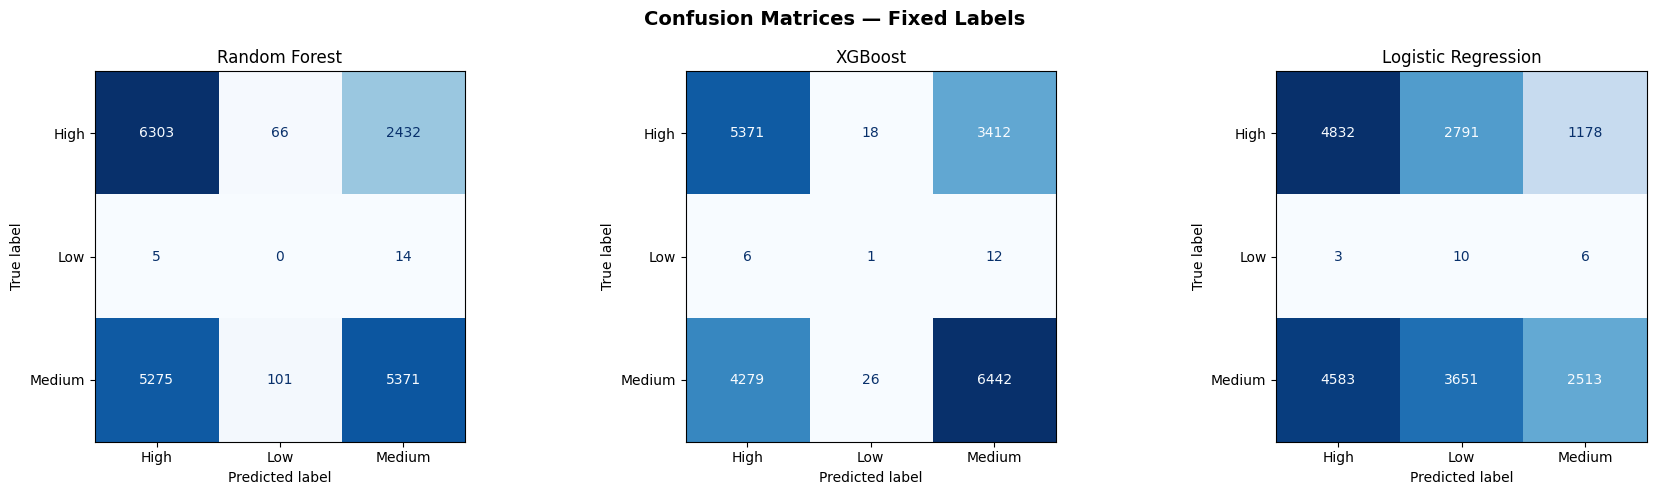

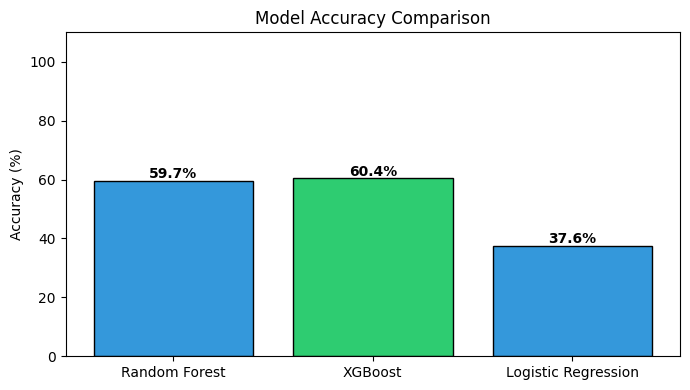


📊 Best Model Report:
              precision    recall  f1-score   support

        High       0.56      0.61      0.58      8801
         Low       0.02      0.05      0.03        19
      Medium       0.65      0.60      0.63     10747

    accuracy                           0.60     19567
   macro avg       0.41      0.42      0.41     19567
weighted avg       0.61      0.60      0.61     19567



In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Fixed Labels',
             fontsize=14, fontweight='bold')

for ax, (name, pred) in zip(axes, [
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
    ('Logistic Regression', lr_pred)]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=le_severity.classes_
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices_fixed.png', dpi=150)
plt.show()

# Accuracy comparison
fig, ax = plt.subplots(figsize=(7, 4))
accs   = [rf_acc, xgb_acc, lr_acc]
names  = ['Random Forest', 'XGBoost', 'Logistic Regression']
colors = ['#2ecc71' if a == max(accs) else '#3498db' for a in accs]
bars   = ax.bar(names, [a*100 for a in accs],
                color=colors, edgecolor='black')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{acc*100:.1f}%',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_fixed.png', dpi=150)
plt.show()

print("\n📊 Best Model Report:")
best_pred = {'Random Forest': rf_pred,
             'XGBoost': xgb_pred,
             'Logistic Regression': lr_pred}[best_name]
print(classification_report(y_test, best_pred,
                             target_names=le_severity.classes_))

### **5. Traffic Data Loading, Preprocessing, and Prediction**

In [62]:
import os
target_keywords = ['Metro', 'Interstate', 'Traffic']

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if all(keyword in file for keyword in target_keywords):
            full_path = os.path.join(root, file)
            print(f"Found: {full_path}")

Found: /content/drive/MyDrive/Metro_Interstate_Traffic_Volume.csv.gz


In [63]:
import pandas as pd
import os

# Path to the compressed file found in the previous cell
file_path_gz = '/content/drive/MyDrive/Metro_Interstate_Traffic_Volume.csv.gz'

os.path.exists(file_path_gz)

# Read the gzipped CSV file directly
trf_df = pd.read_csv(file_path_gz, compression='gzip', parse_dates=['date_time'])
print(f"✅ Loaded! Shape: {trf_df.shape}")
display(trf_df.head(3))


✅ Loaded! Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767


In [64]:
print("🔧 Processing traffic data...")

trf_df['hour']         = trf_df['date_time'].dt.hour
trf_df['day']          = trf_df['date_time'].dt.dayofweek
trf_df['month']        = trf_df['date_time'].dt.month
trf_df['is_weekend']   = (trf_df['day'] >= 5).astype(int)
trf_df['is_holiday']   = (trf_df['holiday'] != 'None').astype(int)
trf_df['is_rush_hour'] = (
    ((trf_df['hour'] >= 7) & (trf_df['hour'] <= 9)) |
    ((trf_df['hour'] >= 17) & (trf_df['hour'] <= 19))
).astype(int)

# Encode weather
le_weather_trf = LabelEncoder()
trf_df['weather_encoded'] = le_weather_trf.fit_transform(
    trf_df['weather_main'])

# Traffic level labels
def traffic_level(vol):
    if vol < 2000:   return 'Low'
    elif vol < 4500: return 'Medium'
    else:            return 'High'

trf_df['Traffic_Level'] = trf_df['traffic_volume'].apply(traffic_level)

# Weather risk score
weather_risk_trf = {
    'Clear':0.1,'Clouds':0.2,'Mist':0.3,'Haze':0.3,
    'Drizzle':0.4,'Rain':0.6,'Fog':0.7,
    'Snow':0.8,'Thunderstorm':0.9,'Squall':0.85
}
trf_df['Weather_Risk'] = trf_df['weather_main'].map(
    weather_risk_trf).fillna(0.3)

print("✅ Traffic preprocessing done!")
print("\nTraffic Level Distribution:")
print(trf_df['Traffic_Level'].value_counts())

🔧 Processing traffic data...
✅ Traffic preprocessing done!

Traffic Level Distribution:
Traffic_Level
High      16967
Medium    16018
Low       15219
Name: count, dtype: int64


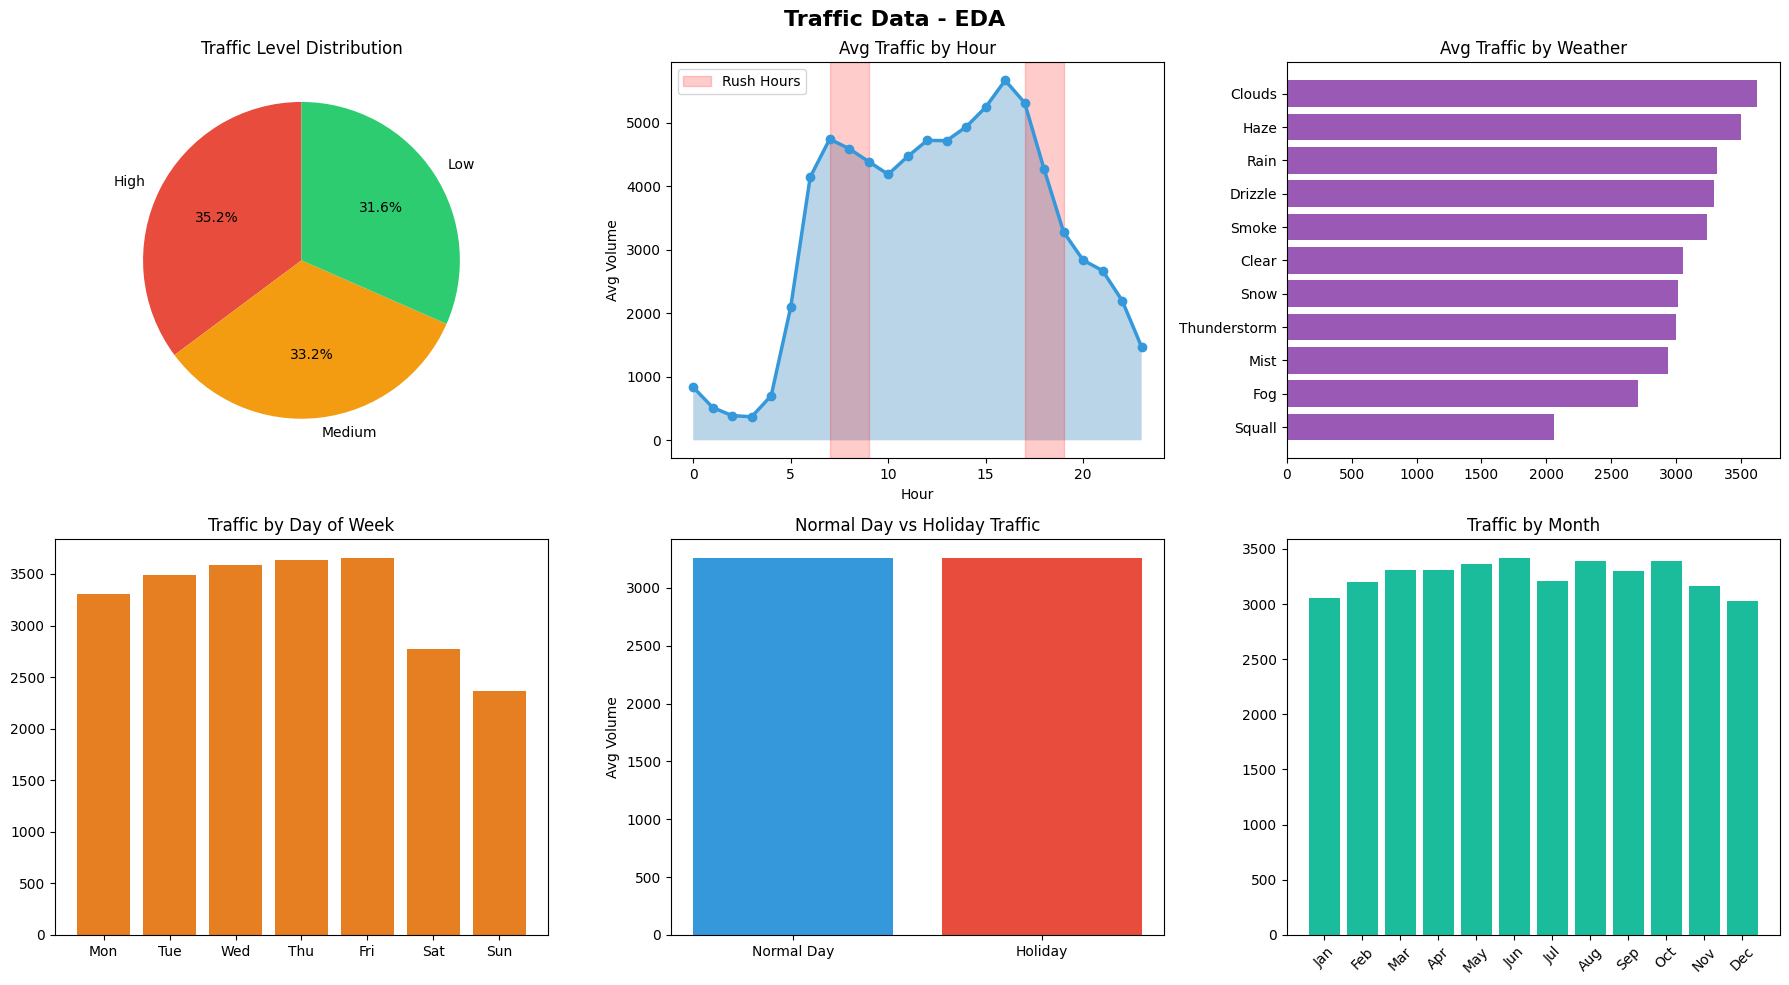

✅ Traffic EDA done!


In [65]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Traffic Data - EDA', fontsize=16, fontweight='bold')

# 1. Traffic Level Distribution
tl = trf_df['Traffic_Level'].value_counts()
colors_tl = {'Low':'#2ecc71','Medium':'#f39c12','High':'#e74c3c'}
axes[0,0].pie(tl.values, labels=tl.index,
              colors=[colors_tl[l] for l in tl.index],
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Traffic Level Distribution')

# 2. Avg Traffic by Hour
hourly_avg = trf_df.groupby('hour')['traffic_volume'].mean()
axes[0,1].plot(hourly_avg.index, hourly_avg.values,
               color='#3498db', linewidth=2.5, marker='o')
axes[0,1].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.3)
axes[0,1].axvspan(7, 9, alpha=0.2, color='red', label='Rush Hours')
axes[0,1].axvspan(17,19, alpha=0.2, color='red')
axes[0,1].set_title('Avg Traffic by Hour')
axes[0,1].set_xlabel('Hour'); axes[0,1].set_ylabel('Avg Volume')
axes[0,1].legend()

# 3. Traffic by Weather
weather_avg = trf_df.groupby('weather_main')['traffic_volume'].mean().sort_values()
axes[0,2].barh(weather_avg.index, weather_avg.values, color='#9b59b6')
axes[0,2].set_title('Avg Traffic by Weather')

# 4. Traffic by Day
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg = trf_df.groupby('day')['traffic_volume'].mean()
axes[1,0].bar(days, dow_avg.values, color='#e67e22')
axes[1,0].set_title('Traffic by Day of Week')

# 5. Holiday vs Normal
hol_avg = trf_df.groupby('is_holiday')['traffic_volume'].mean()
axes[1,1].bar(['Normal Day','Holiday'], hol_avg.values,
              color=['#3498db','#e74c3c'])
axes[1,1].set_title('Normal Day vs Holiday Traffic')
axes[1,1].set_ylabel('Avg Volume')

# 6. Monthly Traffic
monthly_avg = trf_df.groupby('month')['traffic_volume'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,2].bar(month_names, monthly_avg.values, color='#1abc9c')
axes[1,2].set_title('Traffic by Month')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_traffic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Traffic EDA done!")

🤖 Training traffic prediction model...
✅ Traffic Model Accuracy: 0.9104

📊 Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.89      0.91      3546
         Low       0.95      0.96      0.96      2991
      Medium       0.85      0.88      0.87      3104

    accuracy                           0.91      9641
   macro avg       0.91      0.91      0.91      9641
weighted avg       0.91      0.91      0.91      9641



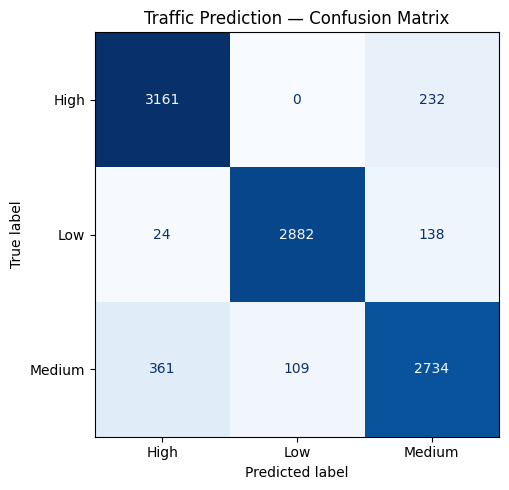

In [66]:
print("🤖 Training traffic prediction model...")

TRAFFIC_FEATURES = ['hour','day','month','is_weekend',
                    'is_holiday','is_rush_hour',
                    'weather_encoded','temp',
                    'rain_1h','snow_1h','clouds_all',
                    'Weather_Risk']

le_traffic = LabelEncoder()
trf_df['Traffic_Encoded'] = le_traffic.fit_transform(
    trf_df['Traffic_Level'])

X_trf = trf_df[TRAFFIC_FEATURES].fillna(0)
y_trf = trf_df['Traffic_Encoded']

X_trf_train, X_trf_test, y_trf_train, y_trf_test = train_test_split(
    X_trf, y_trf, test_size=0.2,
    random_state=42, stratify=y_trf)

scaler_trf    = StandardScaler()
X_trf_train_s = scaler_trf.fit_transform(X_trf_train)
X_trf_test_s  = scaler_trf.transform(X_trf_test)

trf_rf = RandomForestClassifier(
    n_estimators=200, random_state=42,
    n_jobs=-1, class_weight='balanced')
trf_rf.fit(X_trf_train_s, y_trf_train)
trf_pred = trf_rf.predict(X_trf_test_s)
trf_acc  = accuracy_score(y_trf_test, trf_pred)

print(f"✅ Traffic Model Accuracy: {trf_acc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(trf_pred, y_trf_test,
                             target_names=le_traffic.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(
    confusion_matrix(y_trf_test, trf_pred),
    display_labels=le_traffic.classes_
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Traffic Prediction — Confusion Matrix')
plt.tight_layout()
plt.savefig('traffic_cm.png', dpi=150)
plt.show()

### **6. Risk Engine and Route Recommendation System**

In [67]:
print("Defining Risk Engine function...")

def calculate_risk(traffic_level, accident_density, weather_condition):
    """
    Risk = 0.4 × Traffic + 0.4 × Accident + 0.2 × Weather
    """
    traffic_score_map = {
        'Low': 0.2, 'Medium': 0.6, 'High': 1.0
    }
    accident_score_map = {
        'Low': 0.1, 'Moderate': 0.5, 'High': 1.0
    }
    weather_score_map = {
        'Clear':0.1, 'Clouds':0.2, 'Mist':0.3,
        'Haze':0.3,  'Drizzle':0.4, 'Rain':0.6,
        'Fog':0.7,   'Snow':0.8, 'Thunderstorm':0.9,
        'Squall':0.85
    }

    t = traffic_score_map.get(traffic_level, 0.5)
    a = accident_score_map.get(accident_density, 0.3)
    w = weather_score_map.get(weather_condition, 0.3)

    risk_score = round(0.4*t + 0.4*a + 0.2*w, 4)

    if risk_score < 0.25:   category = 'Low'
    elif risk_score < 0.50: category = 'Moderate'
    elif risk_score < 0.75: category = 'High'
    else:                    category = 'Severe'

    return risk_score, category

print("Risk Engine function defined!")

Defining Risk Engine function...
Risk Engine function defined!


Testing and visualizing Risk Engine...


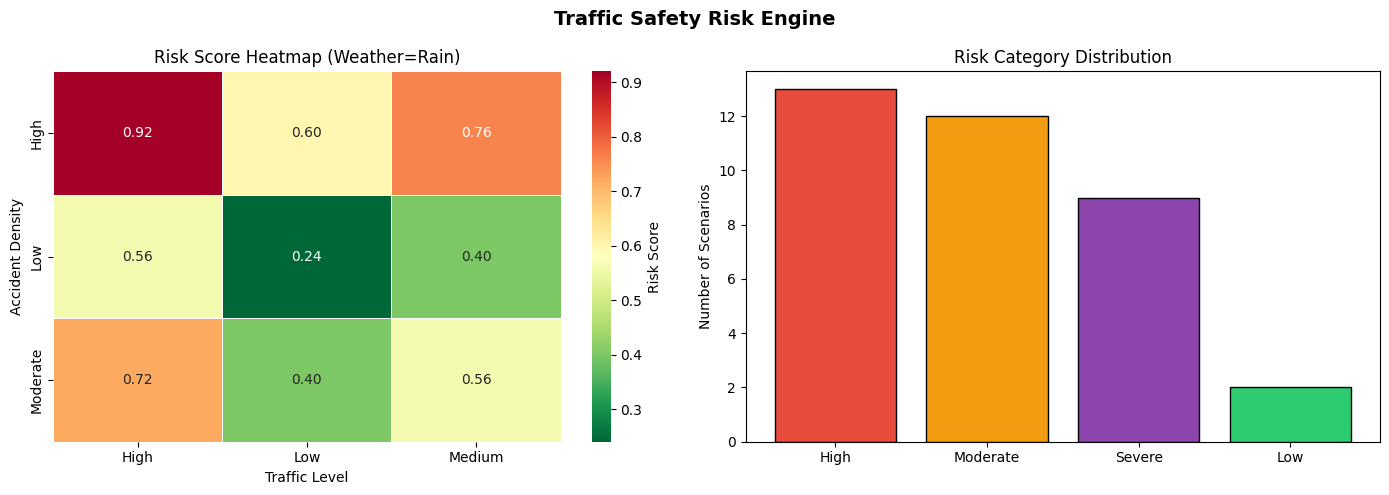

✅ Risk Engine ready!

Sample risk calculations:
  Traffic:Low      Accident:Low        Weather:Clear           → 0.14 (Low)
  Traffic:Medium   Accident:Moderate   Weather:Rain            → 0.56 (High)
  Traffic:High     Accident:High       Weather:Snow            → 0.96 (Severe)
  Traffic:High     Accident:High       Weather:Thunderstorm    → 0.98 (Severe)


In [68]:
print("Testing and visualizing Risk Engine...")

# Test all combinations and visualize
combos = []
for t in ['Low','Medium','High']:
    for a in ['Low','Moderate','High']:
        for w in ['Clear','Rain','Snow','Thunderstorm']:
            s, c = calculate_risk(t, a, w)
            combos.append({
                'Traffic':t, 'Accident':a,
                'Weather':w, 'Score':s, 'Category':c
            })

risk_df = pd.DataFrame(combos)

# Heatmap of risk scores
pivot = risk_df[risk_df['Weather']=='Rain'].pivot(
    index='Accident', columns='Traffic', values='Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Traffic Safety Risk Engine', fontsize=14, fontweight='bold')

# Risk heatmap
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Risk Score'})
axes[0].set_title('Risk Score Heatmap (Weather=Rain)')
axes[0].set_xlabel('Traffic Level')
axes[0].set_ylabel('Accident Density')

# Risk category distribution
cat_counts = risk_df['Category'].value_counts()
colors_cat = {'Low':'#2ecc71','Moderate':'#f39c12',
              'High':'#e74c3c','Severe':'#8e44ad'}
axes[1].bar(cat_counts.index, cat_counts.values,
            color=[colors_cat.get(c,'#3498db')
                   for c in cat_counts.index],
            edgecolor='black')
axes[1].set_title('Risk Category Distribution')
axes[1].set_ylabel('Number of Scenarios')

plt.tight_layout()
plt.savefig('risk_engine.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Risk Engine ready!")
print("\nSample risk calculations:")
print("="*55)
for t,a,w in [('Low','Low','Clear'),
               ('Medium','Moderate','Rain'),
               ('High','High','Snow'),
               ('High','High','Thunderstorm')]:
    s, c = calculate_risk(t, a, w)
    print(f"  Traffic:{t:<8} Accident:{a:<10} "
          f"Weather:{w:<15} → {s} ({c})")
print("="*55)

Building Route Recommendation System...

        ROUTE RECOMMENDATION RESULTS
  Route          Description  Distance(km)  Est.Time(min)  Risk_Score Risk_Level
Route D   Ring Road (safest)          20.3             32      0.2000        Low
Route B  Expressway (longer)          17.2             28      0.3067   Moderate
Route C  Residential Streets          10.1             35      0.5133       High
Route A Highway via Downtown          12.5             22      0.7733     Severe

 SAFEST ROUTE  : Route D
   Description   : Ring Road (safest)
   Distance      : 20.3 km
   Est. Time     : 32 min
   Risk Score    : 0.2
   Risk Level    : Low


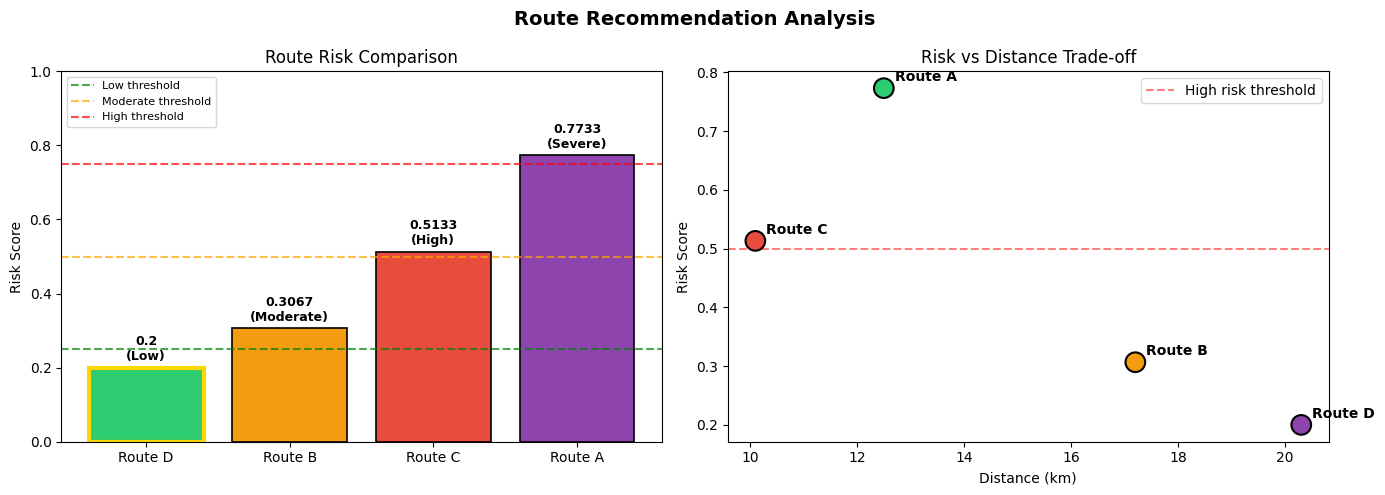

In [69]:
print("Building Route Recommendation System...")

ROUTES = [
    {
        'id': 'Route A',
        'desc': 'Highway via Downtown',
        'distance_km': 12.5,
        'time_min': 22,
        'segments': [
            {'traffic':'High',   'accident':'High',     'weather':'Rain'},
            {'traffic':'High',   'accident':'Moderate', 'weather':'Rain'},
            {'traffic':'Medium', 'accident':'High',     'weather':'Clouds'},
        ]
    },
    {
        'id': 'Route B',
        'desc': 'Expressway (longer)',
        'distance_km': 17.2,
        'time_min': 28,
        'segments': [
            {'traffic':'Medium', 'accident':'Low',      'weather':'Clear'},
            {'traffic':'Low',    'accident':'Low',      'weather':'Clear'},
            {'traffic':'Medium', 'accident':'Moderate', 'weather':'Clouds'},
        ]
    },
    {
        'id': 'Route C',
        'desc': 'Residential Streets',
        'distance_km': 10.1,
        'time_min': 35,
        'segments': [
            {'traffic':'Low',    'accident':'Moderate', 'weather':'Fog'},
            {'traffic':'Medium', 'accident':'Low',      'weather':'Rain'},
            {'traffic':'High',   'accident':'Moderate', 'weather':'Rain'},
        ]
    },
    {
        'id': 'Route D',
        'desc': 'Ring Road (safest)',
        'distance_km': 20.3,
        'time_min': 32,
        'segments': [
            {'traffic':'Low',    'accident':'Low',      'weather':'Clear'},
            {'traffic':'Low',    'accident':'Low',      'weather':'Clear'},
            {'traffic':'Medium', 'accident':'Low',      'weather':'Clouds'},
        ]
    },
]

def evaluate_route(route):
    scores = []
    for seg in route['segments']:
        s, _ = calculate_risk(
            seg['traffic'], seg['accident'], seg['weather'])
        scores.append(s)
    avg = round(np.mean(scores), 4)
    if avg < 0.25:   cat = 'Low'
    elif avg < 0.50: cat = 'Moderate'
    elif avg < 0.75: cat = 'High'
    else:             cat = 'Severe'
    return avg, cat

results = []
for r in ROUTES:
    score, cat = evaluate_route(r)
    results.append({
        'Route'      : r['id'],
        'Description': r['desc'],
        'Distance(km)': r['distance_km'],
        'Est.Time(min)': r['time_min'],
        'Risk_Score' : score,
        'Risk_Level' : cat
    })

res_df      = pd.DataFrame(results).sort_values('Risk_Score')
recommended = res_df.iloc[0]

print("\n" + "="*60)
print("        ROUTE RECOMMENDATION RESULTS")
print("="*60)
print(res_df.to_string(index=False))
print("="*60)
print(f"\n SAFEST ROUTE  : {recommended['Route']}")
print(f"   Description   : {recommended['Description']}")
print(f"   Distance      : {recommended['Distance(km)']} km")
print(f"   Est. Time     : {recommended['Est.Time(min)']} min")
print(f"   Risk Score    : {recommended['Risk_Score']}")
print(f"   Risk Level    : {recommended['Risk_Level']}")
print("="*60)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Route Recommendation Analysis',
             fontsize=14, fontweight='bold')

colors_risk = {'Low':'#2ecc71','Moderate':'#f39c12',
               'High':'#e74c3c','Severe':'#8e44ad'}

# Bar chart - risk scores
bar_colors = [colors_risk.get(l,'#3498db')
              for l in res_df['Risk_Level']]
bars = axes[0].bar(res_df['Route'], res_df['Risk_Score'],
                   color=bar_colors, edgecolor='black', linewidth=1.2)
axes[0].axhline(0.25, color='green',  linestyle='--',
                alpha=0.7, label='Low threshold')
axes[0].axhline(0.50, color='orange', linestyle='--',
                alpha=0.7, label='Moderate threshold')
axes[0].axhline(0.75, color='red',    linestyle='--',
                alpha=0.7, label='High threshold')
axes[0].set_ylabel('Risk Score')
axes[0].set_title('Route Risk Comparison')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
for bar, row in zip(bars, res_df.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.02,
                 f'{row.Risk_Score}\n({row.Risk_Level})',
                 ha='center', fontsize=9,
                 fontweight='bold')
# Gold border on recommended
bars[0].set_edgecolor('gold')
bars[0].set_linewidth(3)

# Scatter - risk vs distance
scatter_colors = [colors_risk.get(
    res_df.loc[res_df['Route']==r['id'],'Risk_Level'].values[0],
    '#3498db') for r in ROUTES]
axes[1].scatter(res_df['Distance(km)'], res_df['Risk_Score'],
                c=scatter_colors, s=200, zorder=5,
                edgecolors='black', linewidth=1.5)
for _, row in res_df.iterrows():
    axes[1].annotate(
        row['Route'],
        (row['Distance(km)'], row['Risk_Score']),
        textcoords='offset points', xytext=(8,5),
        fontsize=10, fontweight='bold')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Risk Score')
axes[1].set_title('Risk vs Distance Trade-off')
axes[1].axhline(0.5, color='red', linestyle='--',
                alpha=0.5, label='High risk threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('route_recommendation.png', dpi=150, bbox_inches='tight')
plt.show()

### **7. Model Saving and Dashboard Deployment**

In [70]:
import subprocess, time
from pyngrok import ngrok


ngrok.set_auth_token("3BQolT3ioRRhTEWqk397URjDWcw_4pV8nPnQRvjqMPcT351V9") # ngrok auth token

subprocess.Popen([
    'streamlit', 'run', 'app.py',
    '--server.port', '8501',
    '--server.address', '0.0.0.0',
    '--server.headless', 'true',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false'
])

time.sleep(10)
public_url = ngrok.connect(8501)
print(f"✅ Live at: {public_url}")

✅ Live at: NgrokTunnel: "https://unresisting-subsimious-katheryn.ngrok-free.dev" -> "http://localhost:8501"


In [71]:
os.makedirs('saved_models', exist_ok=True)

pickle.dump(rf,             open('saved_models/rf_model.pkl','wb'))
pickle.dump(xgb,            open('saved_models/xgb_model.pkl','wb'))
pickle.dump(lr,             open('saved_models/lr_model.pkl','wb'))
pickle.dump(kmeans,         open('saved_models/kmeans.pkl','wb'))
pickle.dump(scaler,         open('saved_models/scaler.pkl','wb'))
pickle.dump(scaler_coords,  open('saved_models/scaler_coords.pkl','wb'))
pickle.dump(le_severity,    open('saved_models/le_severity.pkl','wb'))
pickle.dump(le_weather,     open('saved_models/le_weather.pkl','wb'))
pickle.dump(weather_time_analysis, open('saved_models/weather_time_analysis.pkl','wb')) # Save weather_time_analysis

hotspot_centroids.to_csv('saved_models/centroids.csv', index=False)

pickle.dump(trf_rf,        open('saved_models/trf_rf_model.pkl','wb'))
pickle.dump(scaler_trf,    open('saved_models/scaler_trf.pkl','wb'))
pickle.dump(le_traffic,    open('saved_models/le_traffic.pkl','wb'))
pickle.dump(le_weather_trf,open('saved_models/le_weather_trf.pkl','wb'))

print("✅ All models and data saved to saved_models/")

✅ All models and data saved to saved_models/


In [72]:
print("\n" + "="*60)
print("🚦 SMART TRAFFIC SAFETY SYSTEM — FINAL SUMMARY")
print("="*60)
print(f"  Accident Records     : {len(df):,}")
print(f"  Traffic Records      : {len(trf_df):,}")
print(f"  Hotspots Detected    : 6 clusters")
print(f"  RF Accuracy (Acc.)   : {rf_acc*100:.1f}%")
print(f"  XGB Accuracy (Acc.)  : {xgb_acc*100:.1f}%")
print(f"  Traffic Model Acc.   : {trf_acc*100:.1f}%")
print(f"  Risk Scenarios Built : {len(risk_df)}")
print(f"  Recommended Route    : {recommended['Route']}")
print(f"  Route Risk Score     : {recommended['Risk_Score']}")
print("="*60)
print("\n ALL MODULES COMPLETE!")
print("   Models saved in: saved_models/")
print("   Run streamlit_dashboard.py for the dashboard")
print("="*60)


🚦 SMART TRAFFIC SAFETY SYSTEM — FINAL SUMMARY
  Accident Records     : 97,833
  Traffic Records      : 48,204
  Hotspots Detected    : 6 clusters
  RF Accuracy (Acc.)   : 59.7%
  XGB Accuracy (Acc.)  : 60.4%
  Traffic Model Acc.   : 91.0%
  Risk Scenarios Built : 36
  Recommended Route    : Route D
  Route Risk Score     : 0.2

 ALL MODULES COMPLETE!
   Models saved in: saved_models/
   Run streamlit_dashboard.py for the dashboard


In [73]:

# Use full dataset spread — sample evenly across all states
sample = df.groupby('State', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 300), random_state=42)
).reset_index(drop=True)

print(f"Plotting {len(sample):,} points across {sample['State'].nunique()} states")

# Center of USA
center = [39.5, -98.35]
m = folium.Map(location=center, zoom_start=4,)

# Heatmap
HeatMap(
    sample[['Latitude','Longitude']].values.tolist(),
    radius=18, blur=25, min_opacity=0.3,
    gradient={0.2:'blue', 0.4:'lime',
              0.65:'yellow', 1:'red'}
).add_to(m)

# Hotspot centroids
color_map = {'High':'red', 'Moderate':'orange', 'Low':'green'}
for _, row in hotspot_centroids.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=15,
        color=color_map[row['Density']],
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Accident Hotspot</b><br>"
            f"Density: {row['Density']}<br>"
            f"Lat: {row['Latitude']:.2f}, Lng: {row['Longitude']:.2f}",
            max_width=200)
    ).add_to(m)

# Legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
     background:rgba(0,0,0,0.8); color:white; padding:12px;
     border-radius:8px; font-size:13px;">
  <b>🚦 Accident Hotspot Map</b><br>
  <span style="color:red">●</span> High Density<br>
  <span style="color:orange">●</span> Moderate Density<br>
  <span style="color:green">●</span> Low Density
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('hotspot_map.html')
print("✅ Map saved!")
m

Plotting 602 points across 3 states
✅ Map saved!


In [74]:
os.makedirs('saved_models', exist_ok=True)

pickle.dump(rf,             open('saved_models/rf_model.pkl','wb'))
pickle.dump(xgb,            open('saved_models/xgb_model.pkl','wb'))
pickle.dump(lr,             open('saved_models/lr_model.pkl','wb'))
pickle.dump(kmeans,         open('saved_models/kmeans.pkl','wb'))
pickle.dump(scaler,         open('saved_models/scaler.pkl','wb'))
pickle.dump(scaler_coords,  open('saved_models/scaler_coords.pkl','wb'))
pickle.dump(le_severity,    open('saved_models/le_severity.pkl','wb'))
pickle.dump(le_weather,     open('saved_models/le_weather.pkl','wb'))

hotspot_centroids.to_csv('saved_models/centroids.csv', index=False)

print("✅ All models saved to saved_models/")

✅ All models saved to saved_models/


In [75]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import folium
from streamlit_folium import st_folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

st.set_page_config(
    page_title="Smart Traffic Safety",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Dark theme CSS ────────────────────────────────────────
st.markdown("""
<style>
[data-testid="stAppViewContainer"] { background-color: #0e1117; color: white; }
[data-testid="stSidebar"] { background-color: #1a1d27; }
.metric-box { background:#1e2130; border-radius:8px; padding:20px; margin:5px; }
.metric-label { color:#aaa; font-size:13px; }
.metric-value { color:white; font-size:28px; font-weight:bold; }
.module-done { background:#1a3a2a; color:#2ecc71; padding:12px 18px;
               border-radius:6px; margin:6px 0; font-size:15px; }
.footer { color:#555; font-size:12px; text-align:center;
          border-top:1px solid #333; padding-top:12px; margin-top:30px; }
div[data-testid="stRadio"] > div { flex-direction: column; }
</style>
""", unsafe_allow_html=True)

# ── Load models ───────────────────────────────────────────
@st.cache_resource
def load_models():
    rf         = pickle.load(open('saved_models/rf_model.pkl','rb'))
    xgb        = pickle.load(open('saved_models/xgb_model.pkl','rb'))
    lr         = pickle.load(open('saved_models/lr_model.pkl','rb'))
    trf_rf     = pickle.load(open('saved_models/trf_rf_model.pkl','rb'))
    scaler     = pickle.load(open('saved_models/scaler.pkl','rb'))
    scaler_trf = pickle.load(open('saved_models/scaler_trf.pkl','rb'))
    le_sev     = pickle.load(open('saved_models/le_severity.pkl','rb'))
    le_w       = pickle.load(open('saved_models/le_weather.pkl','rb'))
    le_trf     = pickle.load(open('saved_models/le_traffic.pkl','rb'))
    le_wtrf    = pickle.load(open('saved_models/le_weather_trf.pkl','rb'))
    centroids  = pd.read_csv('saved_models/centroids.csv')
    weather_time_analysis = pickle.load(open('saved_models/weather_time_analysis.pkl', 'rb'))
    # Load pre-computed trend data saved from notebook
    accident_trends = pickle.load(open('saved_models/accident_trends.pkl', 'rb'))
    return (rf, xgb, lr, trf_rf, scaler, scaler_trf,
            le_sev, le_w, le_trf, le_wtrf, centroids,
            weather_time_analysis, accident_trends)

(rf, xgb, lr, trf_rf, scaler, scaler_trf,
 le_sev, le_w, le_trf, le_wtrf, centroids,
 weather_time_analysis, accident_trends) = load_models()

# ── Risk Engine ───────────────────────────────────────────
def calculate_risk(traffic_level, accident_density, weather_condition):
    t_map = {'Low':0.2, 'Medium':0.6, 'High':1.0}
    a_map = {'Low':0.1, 'Moderate':0.5, 'High':1.0}
    w_map = {'Clear':0.1, 'Clouds':0.2, 'Mist':0.3, 'Haze':0.3,
             'Drizzle':0.4, 'Rain':0.6, 'Fog':0.7,
             'Snow':0.8, 'Thunderstorm':0.9, 'Squall':0.85}
    t = t_map.get(traffic_level, 0.5)
    a = a_map.get(accident_density, 0.3)
    w = w_map.get(weather_condition, 0.3)
    score = round(0.4*t + 0.4*a + 0.2*w, 4)
    if score < 0.25:   cat = 'Low'
    elif score < 0.50: cat = 'Moderate'
    elif score < 0.75: cat = 'High'
    else:              cat = 'Severe'
    return score, cat

# ── Helper: dark-themed axes ─────────────────────────────
def dark_ax(ax):
    ax.set_facecolor('#1e2130')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#444')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# ── Sidebar ───────────────────────────────────────────────
with st.sidebar:
    st.markdown("### 🚦 Smart Traffic Safety")
    st.markdown("Najmul Hoda | 02416412822")
    st.markdown("B.Tech ECE 8th Sem")
    st.markdown("Guide: Dr. Shiv Ram Meena")
    st.markdown("GGSIPU Dwarka")
    st.markdown("---")
    st.markdown("### 📍 Navigate")
    page = st.radio("", [
        "Overview",
        "Accident Analysis",
        "Traffic Prediction",
        "Risk Engine",
        "Route Recommendation",
        "Live Maps"
    ])

FOOTER = """<div class='footer'>Smart Traffic Safety System |
Najmul Hoda (02416412822) | B.Tech ECE 8th Sem | GGSIPU |
Guide: Dr. Shiv Ram Meena</div>"""

# ══════════════════════════════════════════════════════════
# PAGE 1 — OVERVIEW
# ══════════════════════════════════════════════════════════
if page == "Overview":
    st.title("Smart Traffic Safety System")
    st.markdown("**Major Project | B.Tech ECE | GGSIPU**")
    st.markdown("---")

    c1, c2, c3, c4 = st.columns(4)
    for col, label, val in zip(
        [c1, c2, c3, c4],
        ["Accidents Analyzed", "Traffic Records", "Hotspots Detected", "Best Accuracy"],
        ["97,833", "48,204", "6", "91.0%"]
    ):
        col.markdown(f"""<div class='metric-box'>
            <div class='metric-label'>{label}</div>
            <div class='metric-value'>{val}</div>
        </div>""", unsafe_allow_html=True)

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Modules Completed")
        for m in [
            "✅ Data Collection and Preprocessing",
            "✅ Exploratory Data Analysis",
            "✅ Accident Hotspot Detection (KMeans K=6)",
            "✅ Severity Prediction (RF + XGBoost + LR)",
            "✅ Traffic Level Prediction (RF - 91%)",
            "✅ Traffic Safety Risk Engine",
            "✅ Route Recommendation System",
            "✅ Interactive Dashboard"
        ]:
            st.markdown(f"<div class='module-done'>{m}</div>", unsafe_allow_html=True)

    with col2:
        st.subheader("Tech Stack")
        tech = pd.DataFrame({
            "Component": ["Language", "ML Models", "Clustering",
                          "Geospatial", "Dashboard", "Platform"],
            "Technology": ["Python 3.10", "Random Forest, XGBoost, LR",
                           "KMeans (K=6)", "Folium", "Streamlit", "Google Colab"]
        })
        st.dataframe(tech, use_container_width=True, hide_index=True)

    st.markdown(FOOTER, unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════
# PAGE 2 — ACCIDENT ANALYSIS
# ══════════════════════════════════════════════════════════
elif page == "Accident Analysis":
    st.title("Accident Data Analysis")
    st.markdown("---")

    c1, c2, c3 = st.columns(3)
    for col, label, val in zip(
        [c1, c2, c3],
        ["Total Records", "High Hotspots", "High Severity"],
        ["97,833", "2,000", "1,935"]
    ):
        col.markdown(f"""<div class='metric-box'>
            <div class='metric-label'>{label}</div>
            <div class='metric-value'>{val}</div>
        </div>""", unsafe_allow_html=True)

    st.markdown("---")

    # ── Row 1: Severity pie + Hourly line ──────────────────
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Severity Distribution")
        fig, ax = plt.subplots(figsize=(5, 5), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        sizes  = [45.4, 30.5, 24.1]
        labels = ['Medium', 'Low', 'High']
        colors = ['#f39c12', '#2ecc71', '#e74c3c']
        ax.pie(sizes, labels=labels, colors=colors,
               autopct='%1.1f%%', startangle=90,
               textprops={'color': 'white', 'fontsize': 13})
        st.pyplot(fig)

    with col2:
        st.subheader("Accidents by Hour")
        hours = list(range(24))
        vals  = [120, 80, 60, 50, 70, 150, 280, 340, 300, 260,
                 240, 250, 270, 260, 250, 280, 340, 370, 320,
                 280, 240, 200, 170, 140]
        fig, ax = plt.subplots(figsize=(5, 4), facecolor='#1e2130')
        dark_ax(ax)
        ax.plot(hours, vals, color='#3498db', linewidth=2, marker='o', markersize=4)
        ax.fill_between(hours, vals, alpha=0.2, color='#3498db')
        ax.axvspan(7,  9,  alpha=0.2, color='red', label='Rush Hours')
        ax.axvspan(17, 19, alpha=0.2, color='red')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Number of Accidents')
        ax.legend(facecolor='#1e2130', labelcolor='white')
        st.pyplot(fig)

    st.markdown("---")

    # ── Row 2: EDA plots (Day of Week + Top States) ────────
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Accidents by Day of Week")
        days     = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        day_vals = [15200, 15800, 15500, 15300, 16100, 10200, 9700]
        fig, ax  = plt.subplots(figsize=(5, 4), facecolor='#1e2130')
        dark_ax(ax)
        ax.bar(days, day_vals, color='#9b59b6')
        ax.set_xlabel('Day of Week')
        ax.set_ylabel('Number of Accidents')
        for i, v in enumerate(day_vals):
            ax.text(i, v + 100, f'{v:,}', ha='center',
                    fontsize=8, color='white')
        st.pyplot(fig)

    with col2:
        st.subheader("Top 10 States by Accidents")
        states     = ['CA', 'FL', 'TX', 'OR', 'VA', 'NY', 'PA', 'SC', 'NC', 'MN']
        state_vals = [18200, 12400, 9800, 6700, 6200, 5800, 5500, 5100, 4900, 4600]
        fig, ax    = plt.subplots(figsize=(5, 4), facecolor='#1e2130')
        dark_ax(ax)
        ax.bar(states, state_vals, color='#e67e22')
        ax.set_xlabel('State')
        ax.set_ylabel('Number of Accidents')
        ax.tick_params(axis='x', rotation=45)
        st.pyplot(fig)

    st.markdown("---")

    # ── Row 3: Weather-Time Heatmap ────────────────────────
    st.subheader("Accident Frequency by Weather Condition and Hour")
    fig_hm, ax_hm = plt.subplots(figsize=(15, 8), facecolor='#0e1117')
    ax_hm.set_facecolor('#0e1117')
    sns.heatmap(
        weather_time_analysis.head(10),
        cmap='viridis', annot=True, fmt='d',
        linewidths=.5, ax=ax_hm,
        cbar_kws={'label': 'Number of Accidents'}
    )
    ax_hm.set_title('Top 10 Weather Conditions vs. Hour of Accident', color='white')
    ax_hm.set_xlabel('Hour of Day', color='white')
    ax_hm.set_ylabel('Weather Condition', color='white')
    ax_hm.tick_params(axis='x', colors='white')
    ax_hm.tick_params(axis='y', colors='white', rotation=0)
    st.pyplot(fig_hm)

    st.markdown("---")

    # ── Row 4: Accident Trends (Week / Month / Year) ───────
    st.subheader("Accident Trends by Week, Month, and Year")

    weekly  = accident_trends['weekly']   # Series indexed by week number
    monthly = accident_trends['monthly']  # Series indexed by month (1-12)
    yearly  = accident_trends['yearly']   # Series indexed by year

    fig_tr, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#1e2130')
    fig_tr.suptitle('Accident Trends by Week, Month, and Year',
                    fontsize=15, fontweight='bold', color='white')

    for ax in axes:
        dark_ax(ax)

    # Accidents by Week
    axes[0].bar(weekly.index.astype(int), weekly.values, color='#9b59b6')
    axes[0].set_title('Accidents by Week of Year')
    axes[0].set_xlabel('Week Number')
    axes[0].set_ylabel('Number of Accidents')
    axes[0].tick_params(axis='x', rotation=45)

    # Accidents by Month
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    axes[1].bar(monthly.index, monthly.values, color='#2ecc71')
    axes[1].set_title('Accidents by Month')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Number of Accidents')
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels(month_names, rotation=45, color='white')

    # Accidents by Year
    axes[2].bar(yearly.index, yearly.values, color='#3498db')
    axes[2].set_title('Accidents by Year')
    axes[2].set_xlabel('Year')
    axes[2].set_ylabel('Number of Accidents')
    axes[2].set_xticks(yearly.index)
    axes[2].set_xticklabels([str(y) for y in yearly.index],
                             rotation=45, color='white')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    st.pyplot(fig_tr)

    st.markdown(FOOTER, unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════
# PAGE 3 — TRAFFIC PREDICTION
# ══════════════════════════════════════════════════════════
elif page == "Traffic Prediction":
    st.title("Traffic Prediction Module")
    st.markdown("---")

    c1, c2, c3 = st.columns(3)
    for col, label, val in zip(
        [c1, c2, c3],
        ["Dataset", "Records", "Accuracy"],
        ["Metro Interstate", "48,204", "91.0%"]
    ):
        col.markdown(f"""<div class='metric-box'>
            <div class='metric-label'>{label}</div>
            <div class='metric-value'>{val}</div>
        </div>""", unsafe_allow_html=True)

    st.markdown("---")

    # ── Traffic EDA Section ────────────────────────────────
    st.subheader("📊 Traffic EDA")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Traffic Level Distribution**")
        fig, ax = plt.subplots(figsize=(5, 5), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        ax.pie([61.6, 38.4],
               labels=['Low', 'Medium'],
               colors=['#2ecc71', '#f39c12'],
               autopct='%1.1f%%', startangle=90,
               textprops={'color': 'white', 'fontsize': 14})
        ax.set_title('Traffic Level Distribution', color='white')
        st.pyplot(fig)

    with col2:
        st.markdown("**Avg Traffic Volume by Hour**")
        hours = list(range(24))
        vals  = [500, 300, 200, 150, 200, 600, 2800, 3050,
                 2400, 2000, 1800, 1900, 2000, 1900, 1800,
                 2100, 2800, 3050, 2600, 2200, 1800, 1400,
                 1000, 700]
        fig, ax = plt.subplots(figsize=(5, 4), facecolor='#1e2130')
        dark_ax(ax)
        ax.plot(hours, vals, color='#e67e22', linewidth=2.5,
                marker='o', markersize=5)
        ax.fill_between(hours, vals, alpha=0.2, color='#e67e22')
        ax.axvspan(7,  9,  alpha=0.2, color='red', label='Rush Hours')
        ax.axvspan(17, 19, alpha=0.2, color='red')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Avg Traffic Volume')
        ax.legend(facecolor='#1e2130', labelcolor='white')
        st.pyplot(fig)

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Avg Traffic Volume by Day of Week**")
        days     = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        day_vals = [2800, 2900, 2850, 2870, 3050, 1800, 1500]
        fig, ax  = plt.subplots(figsize=(5, 4), facecolor='#1e2130')
        dark_ax(ax)
        ax.bar(days, day_vals, color='#9b59b6')
        ax.set_xlabel('Day of Week')
        ax.set_ylabel('Avg Traffic Volume')
        for i, v in enumerate(day_vals):
            ax.text(i, v + 30, f'{v:,}', ha='center',
                    fontsize=8, color='white')
        st.pyplot(fig)

    with col2:
        st.markdown("**Avg Traffic Volume by Month**")
        month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                       'Jul','Aug','Sep','Oct','Nov','Dec']
        month_vals  = [2200, 2100, 2400, 2600, 2700, 2500,
                       2300, 2400, 2600, 2700, 2500, 2100]
        fig, ax = plt.subplots(figsize=(5, 4), facecolor='#1e2130')
        dark_ax(ax)
        ax.bar(range(1, 13), month_vals, color='#3498db')
        ax.set_xlabel('Month')
        ax.set_ylabel('Avg Traffic Volume')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_names, rotation=45, color='white')
        st.pyplot(fig)

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Traffic Volume by Weather Condition**")
        weather_labels = ['Clear', 'Clouds', 'Rain', 'Mist',
                          'Snow', 'Drizzle', 'Fog', 'Thunderstorm']
        weather_vals   = [3100, 2800, 2200, 2400, 1800, 2000, 1600, 1400]
        colors_w = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(weather_labels)))
        fig, ax  = plt.subplots(figsize=(5, 4), facecolor='#1e2130')
        dark_ax(ax)
        bars = ax.barh(weather_labels, weather_vals, color=colors_w)
        ax.set_xlabel('Avg Traffic Volume')
        ax.set_title('Weather vs Traffic Volume', color='white')
        st.pyplot(fig)

    with col2:
        st.markdown("**Rush Hour vs Non-Rush Hour Traffic**")
        fig, ax = plt.subplots(figsize=(5, 4), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        ax.pie([35, 65],
               labels=['Rush Hour', 'Non-Rush Hour'],
               colors=['#e74c3c', '#3498db'],
               autopct='%1.1f%%', startangle=90,
               textprops={'color': 'white', 'fontsize': 13},
               explode=[0.05, 0])
        ax.set_title('Rush Hour Distribution', color='white')
        st.pyplot(fig)

    st.markdown("---")

    # ── Predict Section ────────────────────────────────────
    st.subheader("🚗 Predict Traffic Level")
    col1, col2 = st.columns(2)
    with col1:
        t_weather = st.selectbox("Weather", le_wtrf.classes_)
        t_temp    = st.slider("Temperature (K)", 250.0, 310.0, 288.0)
        t_rain    = st.slider("Rain 1h (mm)", 0.0, 100.0, 0.0)
        t_snow    = st.slider("Snow 1h (mm)", 0.0, 100.0, 0.0)
        t_clouds  = st.slider("Cloud Cover (%)", 0, 100, 40)
    with col2:
        t_hour    = st.slider("Hour", 0, 23, 8)
        t_day     = st.slider("Day of Week", 0, 6, 0)
        t_month   = st.slider("Month", 1, 12, 6)
        t_weekend = st.checkbox("Is Weekend?")
        t_holiday = st.checkbox("Is Holiday?")
        t_rush    = st.checkbox("Is Rush Hour?")

    if st.button("🚗 Predict Traffic"):
        tw_enc = le_wtrf.transform([t_weather])[0]
        wr = {'Clear':0.1, 'Clouds':0.2, 'Mist':0.3, 'Haze':0.3,
              'Drizzle':0.4, 'Rain':0.6, 'Fog':0.7,
              'Snow':0.8, 'Thunderstorm':0.9, 'Squall':0.85
              }.get(t_weather, 0.3)
        feat   = np.array([[t_hour, t_day, t_month,
                            int(t_weekend), int(t_holiday),
                            int(t_rush), tw_enc, t_temp,
                            t_rain, t_snow, t_clouds, wr]])
        feat_s = scaler_trf.transform(feat)
        pred   = trf_rf.predict(feat_s)[0]
        label  = le_trf.inverse_transform([pred])[0]
        color  = {'Low':'green', 'Medium':'orange',
                  'High':'red'}.get(label, 'gray')
        st.markdown(f"## Traffic Level: :{color}[**{label}**]")

    st.markdown(FOOTER, unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════
# PAGE 4 — RISK ENGINE
# ══════════════════════════════════════════════════════════
elif page == "Risk Engine":
    st.title("Traffic Safety Risk Engine")
    st.markdown("---")
    st.latex(r"Risk = 0.4 \times Traffic + 0.4 \times Accident + 0.2 \times Weather")
    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Calculate Risk Score")
        r_traffic  = st.selectbox("Traffic Level", ['Low', 'Medium', 'High'])
        r_accident = st.selectbox("Accident Density", ['Low', 'Moderate', 'High'])
        r_weather  = st.selectbox("Weather",
                                  ['Clear', 'Clouds', 'Mist', 'Haze',
                                   'Drizzle', 'Rain', 'Fog', 'Snow',
                                   'Thunderstorm', 'Squall'])
        if st.button("Calculate Risk", type="primary"):
            score, cat = calculate_risk(r_traffic, r_accident, r_weather)
            color = {'Low':'green', 'Moderate':'orange',
                     'High':'red', 'Severe':'violet'}.get(cat, 'gray')
            st.markdown(f"### Risk Score: `{score}`")
            st.markdown(f"### Risk Category: :{color}[**{cat}**]")

    with col2:
        st.subheader("Full Risk Matrix")
        combos = []
        for t in ['Low', 'Medium', 'High']:
            for a in ['Low', 'Moderate', 'High']:
                for w in ['Clear', 'Rain', 'Snow', 'Thunderstorm']:
                    s, c = calculate_risk(t, a, w)
                    combos.append({'Traffic':t, 'Accident':a,
                                   'Weather':w, 'Score':s, 'Level':c})
        risk_df = pd.DataFrame(combos).sort_values('Score', ascending=False).head(10)
        st.dataframe(risk_df, use_container_width=True, hide_index=True)

    st.markdown(FOOTER, unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════
# PAGE 5 — ROUTE RECOMMENDATION
# ══════════════════════════════════════════════════════════
elif page == "Route Recommendation":
    st.title("Route Recommendation System")
    st.markdown("---")
    st.info("Configure each route - system finds the safest path.")

    ROUTES_DEFAULT = [
        {'id':'Route A', 'desc':'Highway via Downtown',
         'distance_km':12.5, 'time_min':22,
         'traffic':'High', 'accident':'High', 'weather':'Rain'},
        {'id':'Route B', 'desc':'Expressway (longer)',
         'distance_km':17.2, 'time_min':28,
         'traffic':'Medium', 'accident':'Low', 'weather':'Clear'},
        {'id':'Route C', 'desc':'Residential Streets',
         'distance_km':10.1, 'time_min':35,
         'traffic':'Low', 'accident':'Moderate', 'weather':'Fog'},
        {'id':'Route D', 'desc':'Ring Road (safest)',
         'distance_km':20.3, 'time_min':32,
         'traffic':'Low', 'accident':'Low', 'weather':'Clear'},
    ]

    cols = st.columns(4)
    route_inputs = []
    for i, (col, r) in enumerate(zip(cols, ROUTES_DEFAULT)):
        with col:
            st.markdown(f"**{r['id']}**")
            t = st.selectbox("Traffic",
                ['Low','Medium','High'],
                index=['Low','Medium','High'].index(r['traffic']),
                key=f"rt{i}")
            a = st.selectbox("Accident",
                ['Low','Moderate','High'],
                index=['Low','Moderate','High'].index(r['accident']),
                key=f"ra{i}")
            w = st.selectbox("Weather",
                ['Clear','Clouds','Rain','Fog','Snow','Thunderstorm'],
                index=['Clear','Clouds','Rain','Fog','Snow','Thunderstorm'
                       ].index(r['weather'])
                      if r['weather'] in
                      ['Clear','Clouds','Rain','Fog','Snow','Thunderstorm']
                      else 0,
                key=f"rw{i}")
            d  = st.number_input("Distance(km)", value=r['distance_km'], key=f"rd{i}")
            tm = st.number_input("Time(min)", value=float(r['time_min']), key=f"rt2{i}")
            route_inputs.append({'id':r['id'], 'desc':r['desc'],
                                 'distance_km':d, 'time_min':tm,
                                 'traffic':t, 'accident':a, 'weather':w})

    if st.button("Find Safest Route", type="primary"):
        results = []
        for r in route_inputs:
            score, cat = calculate_risk(r['traffic'], r['accident'], r['weather'])
            results.append({'Route':r['id'], 'Description':r['desc'],
                            'Distance(km)':r['distance_km'],
                            'Est.Time(min)':r['time_min'],
                            'Risk Score':score, 'Risk Level':cat})
        res_df = pd.DataFrame(results).sort_values('Risk Score')
        best   = res_df.iloc[0]
        st.success(
            f"RECOMMENDED: {best['Route']} | "
            f"Risk: {best['Risk Score']} ({best['Risk Level']}) | "
            f"Distance: {best['Distance(km)']} km")

        st.subheader("Route Safety Comparison")
        fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
        colors_map = {'Low':'#2ecc71', 'Moderate':'#f39c12',
                      'High':'#e74c3c', 'Severe':'#8e44ad'}
        bar_colors = [colors_map.get(l, '#3498db') for l in res_df['Risk Level']]
        bars = ax.bar(res_df['Route'], res_df['Risk Score'],
                      color=bar_colors, edgecolor='black')
        ax.axhline(0.25, color='green',  linestyle='--', alpha=0.7)
        ax.axhline(0.50, color='orange', linestyle='--', alpha=0.7)
        ax.axhline(0.75, color='red',    linestyle='--', alpha=0.7)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Risk Score')
        patches = [
            mpatches.Patch(color='#8e44ad', label='Severe'),
            mpatches.Patch(color='#e74c3c', label='High'),
            mpatches.Patch(color='#f39c12', label='Moderate'),
            mpatches.Patch(color='#2ecc71', label='Low'),
        ]
        ax.legend(handles=patches, loc='upper right')
        bars[0].set_edgecolor('gold')
        bars[0].set_linewidth(3)
        for bar, row in zip(bars, res_df.itertuples()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.02,
                    f'{row._5}\n({row._6})',
                    ha='center', fontsize=9, fontweight='bold')
        st.pyplot(fig)

    st.markdown(FOOTER, unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════
# PAGE 6 — LIVE MAPS
# ══════════════════════════════════════════════════════════
elif page == "Live Maps":
    st.title("Geospatial Visualization")
    st.markdown("---")

    map_type  = st.radio("Map Type",
                         ["Heatmap", "Hotspot Clusters", "Risk Zones"],
                         horizontal=True)
    color_map = {'High':'red', 'Moderate':'orange', 'Low':'green'}

    if map_type == "Hotspot Clusters":
        st.subheader("Accident Hotspot Clusters")
        m = folium.Map(location=[34.05, -118.25], zoom_start=8,)
        for _, row in centroids.iterrows():
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=20,
                color=color_map.get(row['Density'], 'blue'),
                fill=True, fill_opacity=0.8,
                popup=folium.Popup(
                    f"<b>Hotspot</b><br>"
                    f"Density: {row['Density']}<br>"
                    f"Lat: {row['Latitude']:.2f}, "
                    f"Lng: {row['Longitude']:.2f}",
                    max_width=200)
            ).add_to(m)
        st_folium(m, width=900, height=500)

    elif map_type == "Heatmap":
        st.subheader("Accident Heatmap")
        from folium.plugins import HeatMap
        m = folium.Map(location=[37.0, -95.0], zoom_start=4,)
        heat_data = centroids[['Latitude', 'Longitude']].values.tolist()
        HeatMap(heat_data, radius=40, blur=30,
                gradient={0.2:'blue', 0.4:'lime',
                          0.65:'yellow', 1:'red'}).add_to(m)
        st_folium(m, width=900, height=500)

    else:
        st.subheader("Risk Zones")
        m = folium.Map(location=[37.0, -95.0], zoom_start=4,)
        for _, row in centroids.iterrows():
            folium.Circle(
                location=[row['Latitude'], row['Longitude']],
                radius=80000,
                color=color_map.get(row['Density'], 'blue'),
                fill=True, fill_opacity=0.3,
                popup=f"Risk Zone: {row['Density']}"
            ).add_to(m)
        st_folium(m, width=900, height=500)

    st.markdown(FOOTER, unsafe_allow_html=True)

Writing app.py


In [76]:
import os
print(os.path.exists('app.py'))

True


In [77]:
# Close Everthing
!pkill -f streamlit
!pkill -f ngrok

from pyngrok import ngrok
ngrok.kill()  # all old tunnels will be closed

import time
time.sleep(3)
print("✅ Everthing closed")

✅ Everthing closed


In [78]:
import subprocess, time
from pyngrok import ngrok

ngrok.set_auth_token("3BQolT3ioRRhTEWqk397URjDWcw_4pV8nPnQRvjqMPcT351V9")

subprocess.Popen([
    'streamlit', 'run', 'app.py',
    '--server.port', '8501',
    '--server.address', '0.0.0.0',
    '--server.headless', 'true',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false'
])

time.sleep(10)
public_url = ngrok.connect(8501)
print(f"✅ Live at: {public_url}")

✅ Live at: NgrokTunnel: "https://unresisting-subsimious-katheryn.ngrok-free.dev" -> "http://localhost:8501"
